1.จากตาราง confusion matrix ด้านล่างให้แสดงการคำนวณค่าต่างๆ ดังต่อไปนี้
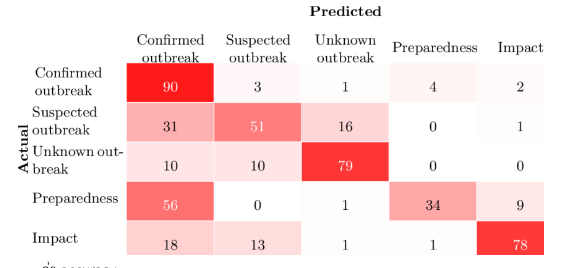



- ค่า accuracy
acuracy = TP/N

N = 90+3+1+4+2+31+51+16+0+1+10+10+79+0+0+56+0+1+34+9+18+13+1+1+78 = 509
ค่าแนวทแยง
TP-total = 90+51+79+34+78 = 332

accuracy = 332/509 ~ 0.652...

- ค่า precision ของคลาส preparedness
precision = TP/TP+FP
TP = คือกรณีที่ทำนาย Preparedness ถูกต้อง
FP = คือกรณีที่ทำนายเป็น Preparedness แต่จริงไม่ใช่

TP = 34 ในแนวทแยง
FP = 4+0+0+1 = 5

presision = 34/34+5 ~ 0.872

- ค่า F1-score ของคลาส unknow outbreak
TP = 79
FP = 1+1+16+1 = 19
FN = 10+10+0+0 = 20
presision = TP/TP+FP
recall = TP/TP+FN
F1 = 2*persision*recall/presision+recall

presision = 79/79+19 = 0.806
recall = 79/79+20 = 0.798
F1-scall = 2*(0.806)(0.798)/(0.806)+(0.798) = 0.801

- ค่า recall micro average
ผลรวมTP = 332
ผลรวม(TP+FN) = 509
recall micro average = ผลรวมTP / ผลรวม(TP+FN)
recall micro average = 332/509 = 0.652



2.

In [2]:

import pandas as pd
df = pd.read_csv("./dataset/SarcasmDataset.csv")
df


,texts,class
0,สวัสดีวันพุธมีความสุขตลอดวันครับ,1
1,งานน้าหลานเมามีความสุขหลาย,1
2,เราถือว่าเราคุ้มมีความสุข,1
3,มีความสุขต้อนรับวันแรกของปีพ่อแม่ลูก,1
4,ยิ้มซิยิ้มมีความสุข,1
...,...,...
10719,ซื้อไข่บอน​กระดาษ​ด่าง​มา​เพาะ​ต้นแข็งแรง​สมบู...,0
10720,ดอกเดียวรู้เรื่อง555555อย่างเกลือตู้นี้ได้SSRแ...,0
10721,อย่าเอานิสัยของตัวเองมาเป็นมาตรฐานวัดนิสัยของค...,0
10722,คนดวงดีก็งี้แหละ555555,0


In [ ]:
from sklearn.utils import shuffle
df = shuffle(df, random_state=0)
print(df)

                                                  texts  class
3474                   เที่ยงแล้วแดดออกแต่มีลมหนาวพัดมา      1
8875                   ไม่เห็นจะเย็นเลย...อาบได้สบายย--      0
5693  ถึงจะมาทำงานสาย??????แต่ก็เลิกงานตรงเวลาน่ะ555...      0
294                       หวัดดีความอ้วนสุขใจที่บ้านเรา      1
2984               เลิกงานแพ็คของส่งของรับตังค์กลับบ้าน      1
...                                                 ...    ...
2230           ประถมมต้นจนมีซะมีลูกแล้วมิตรภาพของเพื่อน      1
3222              วันพระใหญ่ขอให้ต่อไปนี้เจอแต่เรื่องดี      1
6493  มีเวลาเลยแต่งเล่นเพราะว่างมากกกกกก????ไม่มีงาน...      0
9372                          อากาศน่าไปโรงเรียนมากกกกก      0
1023                            ตื่นมาบอกคำดีดีสิ่งดีดี      1

[10724 rows x 2 columns]


In [13]:
import nltk
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize
import re
import string
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/night/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [14]:

import pythainlp
from pythainlp.util import emoji_to_thai

#function for converting emoji to thai word
def thai_emoji(text):
    text_emoji = emoji_to_thai(text)
    return text_emoji

#function for removing number
def remove_numbers(text):
    number_pattern = r'\d+'
    without_number = re.sub(pattern=number_pattern, repl=" ", string=text)
    return without_number

#function for removing punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

#function for removing stopword
def remove_stopwords(text):
    removed = []
    #stop_words = list(stopwords.words("english"))
    stopwords = list(thai_stopwords())
    tokens = word_tokenize(text)
    for i in range(len(tokens)):
        if tokens[i] not in stopwords:
            removed.append(tokens[i])
    return "".join(removed)


#function for removing not thai
def remove_not_thai(text):
    thai = []
    for i in range(len(text)):
      if text[i] in pythainlp.thai_characters and text[i] not in pythainlp.thai_digits:
        thai.append(text[i])
    return "".join(thai)

#function for removing wite_spaces
def remove_extra_white_spaces(text):
    space_pattern = r'\s+'
    without_sc = re.sub(pattern=space_pattern, repl="", string=text)
    return without_sc



In [15]:
#Cleaning text

df['texts'] = df['texts'].apply(lambda x: thai_emoji(x)) #convert emoji to thai
df['texts'] = df['texts'].apply(lambda x: remove_numbers(x)) #remove number
df['texts'] = df['texts'].apply(lambda x: remove_punctuation(x)) #remove punc
df['texts'] = df['texts'].apply(lambda x: remove_stopwords(x)) #remove stopword
df['texts'] = df['texts'].apply(lambda x: remove_not_thai(x)) #remove not thai
df['texts'] = df['texts'].apply(lambda x: remove_extra_white_spaces(x)) #remove space


df.head()

,texts,class
3474,เที่ยงแดดออกลมหนาวพัด,1
8875,ไม่เห็นจะเย็นอาบย,0
5693,ทำงานสายเลิกงานตรงเวลามั่ย,0
294,หวัดดีความอ้วนสุขใจบ้าน,1
2984,เลิกงานแพ็คตังค์กลับบ้าน,1


In [16]:
#binary weighting
def thai_tokenizer(text):
    return word_tokenize(text)

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(tokenizer=thai_tokenizer,token_pattern=None,binary=True)
vectorX = vectorizer.fit_transform(df['texts'])
vectorX = pd.DataFrame(vectorX.toarray(), columns=vectorizer.get_feature_names_out())
vectorX

,ก,กก,กค,กง,กฎ,กฎหมาย,กฏ,กฐิน,กด,กดดัน,...,๊านนนนน,์,์ซ,์ว์,์ไลส,ํ,ํา,ํ่,ํํ,๏
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10719,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10720,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10721,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10722,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#get  X, Y to numpy array

Y = df['class'].to_numpy()
X = vectorX.to_numpy()
type(Y)

numpy.ndarray

In [18]:
#create model
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)



In [19]:
#evaluate model by using k-cross validation
from statistics import mean, stdev
from sklearn.model_selection import KFold
#from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

k = 3
skf = KFold(n_splits=k)
#skf = StratifiedKFold(n_splits=k)
acc = []

presicion_class_fold=[]
presicion_Allclass=[]
presicion_class1=[]
presicion_class2=[]


recall_class_fold=[]
recall_Allclass=[]
recall_class1=[]
recall_class2=[]


f1_class_fold=[]
f1_Allclass=[]
f1_class1=[]
f1_class2=[]

macroavg_recall=[]
macroavg_precision =[]
macroavg_fl = []

i = 0
for train_index, test_index in skf.split(X, Y):
    x_train_fold, x_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = Y[train_index], Y[test_index]

    knn_model.fit(x_train_fold, y_train_fold)
    pred = knn_model.predict(x_test_fold)
    # conf = confusion_matrix(y_test_fold, pred)
    # print(conf)

    #find accuracy for each round
    acc.append(knn_model.score(x_test_fold, y_test_fold))

    #find precision of each class for each round
    presicion_class_fold = precision_score(y_test_fold, pred,average=None)

    presicion_Allclass.append(presicion_class_fold)
    presicion_class1.append(presicion_class_fold[0])
    presicion_class2.append(presicion_class_fold[1])

    #find recall of each class for each round
    recall_class_fold = recall_score(y_test_fold, pred,average=None)
    recall_Allclass.append(recall_class_fold)
    recall_class1.append(recall_class_fold[0])
    recall_class2.append(recall_class_fold[1])

    #find f1 of each class for each round
    f1_class_fold = f1_score(y_test_fold, pred,average=None)
    f1_Allclass.append(f1_class_fold)
    f1_class1.append(f1_class_fold[0])
    f1_class2.append(f1_class_fold[1])

    #find macro average for each round
    precision_fold = precision_score(y_test_fold, pred,average='macro')
    recall_fold = recall_score(y_test_fold, pred,average='macro')
    f1_fold = f1_score(y_test_fold,pred,average='macro')
    macroavg_recall.append(recall_fold)
    macroavg_precision.append(precision_fold)
    macroavg_fl.append(f1_fold)

print('\nAccuracy : %.2f' %(mean(acc)*100), '%')
print('\nStandard Deviation : %.2f' %stdev(acc))

print('------------------------------------------------------------------')
print('Precision for each class =>',presicion_Allclass)
print('Average precision of class1 : %.2f' %(mean(presicion_class1)*100), '%')
print('Average precision of class2 : %.2f' %(mean(presicion_class2)*100), '%')

print('------------------------------------------------------------------')
print('Recall for each class =>',recall_Allclass)
print('Average recall of class1 : %.2f' %(mean(recall_class1)*100), '%')
print('Average recall of class2 : %.2f' %(mean(recall_class2)*100), '%')

print('------------------------------------------------------------------')
print('f1 for each class =>',f1_Allclass)
print('Average f1-score of class1 : %.2f' %(mean(f1_class1)*100), '%')
print('Average f1-score of class2 : %.2f' %(mean(f1_class2)*100), '%')
print('------------------------------------------------------------------')

print('macro average')
print('Average of macro average recall : %.2f' %(mean(macroavg_recall)*100), '%')
print('Average of macro average precision : %.2f' %(mean(macroavg_precision)*100), '%')
print('Average of macro average f1 : %.2f' %(mean(macroavg_fl)*100), '%')
print('------------------------------------------------------------------')


Accuracy : 73.04 %

Standard Deviation : 0.01
------------------------------------------------------------------
Precision for each class => [array([0.67664931, 0.85680566]), array([0.65556018, 0.87478705]), array([0.65776294, 0.85568761])]
Average precision of class1 : 66.33 %
Average precision of class2 : 86.24 %
------------------------------------------------------------------
Recall for each class => [array([0.89546238, 0.59378408]), array([0.91458454, 0.55393743]), array([0.90263459, 0.55142232])]
Average recall of class1 : 90.42 %
Average recall of class2 : 56.64 %
------------------------------------------------------------------
f1 for each class => [array([0.77082818, 0.70144928]), array([0.76370694, 0.67833554]), array([0.76098503, 0.67065868])]
Average f1-score of class1 : 76.52 %
Average f1-score of class2 : 68.35 %
------------------------------------------------------------------
macro average
Average of macro average recall : 73.53 %
Average of macro average precision 